# Phase 4 — NYC TLC → Casablanca Demand Synthesis

**Goal**: Extract statistical fingerprints from NYC TLC Q1 2023 and generate ~500k realistic Casablanca trip requests over 90 days calibrated to Casa population, MAD fare structure, and the Moroccan **Petit / Grand taxi** fleet split.

**Inputs**: `data/nyc-tlc/yellow_tripdata_2023-{01,02,03}.parquet`, `data/zone_mapping.csv`, `data/.osrm_route_cache.json`, `data/curated_trajectories_v4.parquet`  
**Outputs**: `data/casa_synthesis/{casa_trip_requests,casa_hourly_demand,casa_od_matrix}.parquet` + `nyc_to_casa_zone_bridge.csv` + EDA figures

In [1]:
"""Phase 4.0 — Imports, paths, and global config."""
from __future__ import annotations
import json, math, random, hashlib, warnings
from pathlib import Path
from datetime import timedelta

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

ROOT   = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
NYC_DIR = ROOT / 'data' / 'nyc-tlc'
OUT_DIR = ROOT / 'data' / 'casa_synthesis'
OUT_DIR.mkdir(parents=True, exist_ok=True)

ZONE_MAP_CSV = ROOT / 'data' / 'zone_mapping.csv'
OSRM_CACHE   = ROOT / 'data' / '.osrm_route_cache.json'
PORTO_REF    = ROOT / 'data' / 'curated_trajectories_v4.parquet'

RNG_SEED   = 42
N_TRIPS    = 500_000   # ~5.5k/day × 90 days
N_DAYS     = 90
START_DATE = pd.Timestamp.now(tz='UTC').floor('D')

print(f'ROOT       = {ROOT}')
print(f'NYC_DIR    = {NYC_DIR}   files={sorted(p.name for p in NYC_DIR.glob("*.parquet"))}')
print(f'OUT_DIR    = {OUT_DIR}')
print(f'START_DATE = {START_DATE}   horizon={N_DAYS} days   target_trips={N_TRIPS:,}')


ROOT       = c:\Users\hp\OneDrive - Université Abdelmalek Essaadi\Desktop\Taasimm
NYC_DIR    = c:\Users\hp\OneDrive - Université Abdelmalek Essaadi\Desktop\Taasimm\data\nyc-tlc   files=['yellow_tripdata_2023-01.parquet', 'yellow_tripdata_2023-02.parquet', 'yellow_tripdata_2023-03.parquet']
OUT_DIR    = c:\Users\hp\OneDrive - Université Abdelmalek Essaadi\Desktop\Taasimm\data\casa_synthesis
START_DATE = 2026-04-21 00:00:00+00:00   horizon=90 days   target_trips=500,000


## 1. Load & Clean NYC TLC Q1 2023

Read the 3 monthly parquets, normalize the `Airport_fee` ↔ `airport_fee` schema drift,
then apply a realism filter (matches Phase 3 urban gate):
- trip_distance ∈ [0.2, 60] mi · fare_amount ∈ [$2.5, $250]
- passenger_count ∈ [1, 6] · valid pickup/dropoff datetimes
- derived duration ∈ [60 s, 3 h] · avg speed ∈ [3, 90] mph


In [2]:
KEEP_COLS = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'passenger_count', 'trip_distance',
    'PULocationID', 'DOLocationID',
    'fare_amount', 'total_amount', 'payment_type',
]

def _load_month(fp: Path) -> pd.DataFrame:
    df = pq.read_table(fp, columns=KEEP_COLS).to_pandas()
    df['source_month'] = fp.stem[-7:]   # '2023-01' etc.
    return df

nyc_raw = pd.concat([_load_month(p) for p in sorted(NYC_DIR.glob('*.parquet'))],
                    ignore_index=True)
print(f'Raw NYC rows: {len(nyc_raw):,}   ({nyc_raw.source_month.value_counts().to_dict()})')

# --- Feature engineering ---
nyc_raw['duration_s']    = (nyc_raw['tpep_dropoff_datetime']
                            - nyc_raw['tpep_pickup_datetime']).dt.total_seconds()
nyc_raw['avg_speed_mph'] = np.where(
    nyc_raw['duration_s'] > 0,
    nyc_raw['trip_distance'] / (nyc_raw['duration_s'] / 3600.0),
    0.0,
)
nyc_raw['hour'] = nyc_raw['tpep_pickup_datetime'].dt.hour.astype('Int16')
nyc_raw['dow']  = nyc_raw['tpep_pickup_datetime'].dt.dayofweek.astype('Int16')

# --- Quality filter ---
mask = (
    nyc_raw['trip_distance'].between(0.2, 60) &
    nyc_raw['fare_amount'].between(2.5, 250) &
    nyc_raw['passenger_count'].between(1, 6) &
    nyc_raw['duration_s'].between(60, 10_800) &
    nyc_raw['avg_speed_mph'].between(3, 90) &
    nyc_raw['PULocationID'].between(1, 263) &
    nyc_raw['DOLocationID'].between(1, 263) &
    (nyc_raw['tpep_pickup_datetime'].dt.year == 2023)
)
nyc = nyc_raw[mask].copy()
print(f'After realism filter: {len(nyc):,} ({100*len(nyc)/len(nyc_raw):.1f}%)')

print('\nKey distributions:')
print(nyc[['trip_distance','duration_s','avg_speed_mph','fare_amount','passenger_count']]
      .describe().round(2).to_string())

del nyc_raw


Raw NYC rows: 9,384,487   ({'2023-03': 3403766, '2023-01': 3066766, '2023-02': 2913955})
After realism filter: 8,573,788 (91.4%)

Key distributions:
       trip_distance  duration_s  avg_speed_mph  fare_amount  passenger_count
count     8573788.00  8573788.00     8573788.00   8573788.00       8573788.00
mean            3.37      895.90          11.90        18.40             1.38
std             4.26      685.34           6.54        15.91             0.88
min             0.20       60.00           3.00         2.80             1.00
25%             1.10      441.00           7.74         9.30             1.00
50%             1.80      708.00          10.08        12.80             1.00
75%             3.31     1124.00          13.76        20.50             1.00
max            59.52    10776.00          90.00       250.00             6.00


## 2. Extract NYC Fingerprints

Statistical shapes (not values) we carry over to Casa:
- **Hourly curve** (24,) · **Day-of-week curve** (7,) · **hour×dow heatmap** (24,7)
- **Trip-distance histogram** + passenger mix + fare-per-mile regression
- **Per-zone volume tiers** (5 tiers to match Casa A-E cardinality)
- **Tier-to-tier OD flow matrix** (5×5) to seed Casa OD


In [3]:
# --- 2.1 Time-of-day + day-of-week fingerprints ---
hourly  = nyc.groupby('hour', observed=True).size().reindex(range(24), fill_value=0)
dow     = nyc.groupby('dow',  observed=True).size().reindex(range(7),  fill_value=0)
hxd     = (nyc.groupby(['hour','dow'], observed=True).size()
              .unstack(fill_value=0).reindex(index=range(24), columns=range(7), fill_value=0))

NYC_HOURLY_P = (hourly / hourly.sum()).to_numpy()
NYC_DOW_P    = (dow    / dow.sum()).to_numpy()
NYC_HXD_P    = (hxd    / hxd.values.sum()).to_numpy()   # shape (24,7)

print('NYC hourly curve peak-at:',
      int(np.argmax(NYC_HOURLY_P)), 'h   trough-at:', int(np.argmin(NYC_HOURLY_P)), 'h')
print('Morning vs evening demand: '
      f'{NYC_HOURLY_P[7:10].sum()*100:.1f}% (07-09) vs {NYC_HOURLY_P[17:20].sum()*100:.1f}% (17-19)')
print('Weekday share: '
      f'{NYC_DOW_P[:5].sum()*100:.1f}%   weekend: {NYC_DOW_P[5:].sum()*100:.1f}%')

# --- 2.2 Distance + fare + passenger-count fingerprints ---
# Distance: work in km from miles (1 mi = 1.609 km). Apply Casa urban clip [1.5, 18] km.
nyc_km = nyc['trip_distance'] * 1.609
dist_km_samples = nyc_km.clip(lower=1.5, upper=18.0).sample(200_000, random_state=RNG_SEED).to_numpy()
print(f'\nDistance km (after clip): mean={dist_km_samples.mean():.2f}  '
      f'p50={np.percentile(dist_km_samples,50):.2f}  p95={np.percentile(dist_km_samples,95):.2f}')

# Passenger mix
pax_mix = nyc['passenger_count'].value_counts(normalize=True).sort_index()
print('\nPassenger-count mix (NYC):')
for p, f in pax_mix.items():
    print(f'  {int(p)} pax : {f*100:5.1f}%')

# Fare-per-mile (we discard $/mi and use Casa MAD rates later — this is for reference)
nyc['dollar_per_mile'] = nyc['fare_amount'] / nyc['trip_distance'].clip(lower=0.2)
print(f'\nFare-per-mile median (NYC): ${nyc.dollar_per_mile.median():.2f} — '
      'not transferred (Casa uses MAD).')

# --- 2.3 Save passenger distribution for synthesis ---
PAX_VALUES = pax_mix.index.astype(int).to_numpy()
PAX_P      = pax_mix.to_numpy()
PAX_P      = PAX_P / PAX_P.sum()

print('\nStored fingerprints: NYC_HOURLY_P, NYC_DOW_P, NYC_HXD_P, PAX_VALUES, PAX_P, dist_km_samples')


NYC hourly curve peak-at: 18 h   trough-at: 4 h
Morning vs evening demand: 10.8% (07-09) vs 20.5% (17-19)
Weekday share: 73.2%   weekend: 26.8%

Distance km (after clip): mean=4.90  p50=2.90  p95=18.00

Passenger-count mix (NYC):
  1 pax :  77.2%
  2 pax :  15.0%
  3 pax :   3.6%
  4 pax :   1.8%
  5 pax :   1.5%
  6 pax :   1.0%

Fare-per-mile median (NYC): $6.96 — not transferred (Casa uses MAD).

Stored fingerprints: NYC_HOURLY_P, NYC_DOW_P, NYC_HXD_P, PAX_VALUES, PAX_P, dist_km_samples


In [4]:
# --- 2.4 NYC zone volume tiers (pickup + dropoff counts) ---
pu_cnt = nyc.groupby('PULocationID', observed=True).size()
do_cnt = nyc.groupby('DOLocationID', observed=True).size()
zone_vol = (pu_cnt.add(do_cnt, fill_value=0)
                  .sort_values(ascending=False)
                  .astype(int)
                  .rename_axis('nyc_zone_id'))
zone_vol = zone_vol.reset_index(name='volume')

# Bin into 5 tiers to mirror Casa A-E cardinality (2/4/5/4/1 = 16 total, different counts but
# same 5-class structure). Tier A = top ~8% volume, B = next ~25%, C = middle ~33%, D = next ~25%, E = bottom ~8%.
TIER_QUANTILES = [1.0, 0.92, 0.67, 0.34, 0.08, 0.0]   # cumulative (high -> low)
TIER_LABELS    = list('ABCDE')

ranks = (zone_vol['volume'].rank(method='first', ascending=False) - 1) / (len(zone_vol) - 1)
# rank 0 = top. Map to tier by percentile thresholds.
def _to_tier(r):
    if r <= 0.08:  return 'A'
    if r <= 0.33:  return 'B'
    if r <= 0.66:  return 'C'
    if r <= 0.92:  return 'D'
    return 'E'
zone_vol['tier'] = ranks.apply(_to_tier)

NYC_TIER_MAP = zone_vol.set_index('nyc_zone_id')['tier'].to_dict()
print('NYC zone counts per tier:')
print(zone_vol.groupby('tier').agg(n_zones=('nyc_zone_id','count'),
                                    total_vol=('volume','sum')).to_string())

# --- 2.5 Tier-to-tier OD flow matrix (5x5, row-normalized = P(dest_tier | origin_tier)) ---
nyc['o_tier'] = nyc['PULocationID'].map(NYC_TIER_MAP)
nyc['d_tier'] = nyc['DOLocationID'].map(NYC_TIER_MAP)
od_counts = (nyc.groupby(['o_tier','d_tier']).size()
                .unstack(fill_value=0)
                .reindex(index=TIER_LABELS, columns=TIER_LABELS, fill_value=0))
NYC_TIER_OD_P = od_counts.div(od_counts.sum(axis=1), axis=0).to_numpy()
# Origin tier marginal (used to weight Casa origin sampling)
NYC_ORIGIN_TIER_P = (od_counts.sum(axis=1) / od_counts.values.sum()).to_numpy()

print('\nNYC origin-tier marginal (row-normalized):')
for t, p in zip(TIER_LABELS, NYC_ORIGIN_TIER_P):
    print(f'  {t}: {p*100:5.2f}%')

print('\nNYC tier OD flow matrix P(dest|origin):')
print(pd.DataFrame(NYC_TIER_OD_P, index=TIER_LABELS,
                   columns=TIER_LABELS).round(3).to_string())


NYC zone counts per tier:
      n_zones  total_vol
tier                    
A          21   10473043
B          65    6329593
C          85     290880
D          68      52521
E          21       1539

NYC origin-tier marginal (row-normalized):
  A: 65.56%
  B: 33.87%
  C:  0.47%
  D:  0.09%
  E:  0.00%

NYC tier OD flow matrix P(dest|origin):
       A      B      C      D      E
A  0.603  0.366  0.027  0.004  0.000
B  0.501  0.465  0.029  0.005  0.000
C  0.198  0.376  0.339  0.085  0.001
D  0.107  0.286  0.394  0.210  0.003
E  0.101  0.348  0.135  0.225  0.191


## 3. Build NYC → Casa Zone Bridge

Each Casa arrondissement gets an **A-E tier** derived from its population & commercial
centrality (Phase-3 classification used in `03_porto_trajectory_warping.ipynb`).

The bridge maps every NYC zone to the **matching Casa tier** and records the mapping
rationale. Used only for calibrating OD flows — no NYC geography leaks into the final
Casa synthetic dataset.


In [6]:
# --- 3.1 Load 16 Casa zones + apply Phase-3 A-E classification ---
# The geojson does not always carry ae_class (depends on which build wrote it),
# so we declare the Phase-3 classification inline — source of truth for Phase 4.
zone_map_df = pd.read_csv(ZONE_MAP_CSV)

# Phase-3 classification (from 03_porto_trajectory_warping.ipynb, session 4):
CASA_AE_CLASS = {
    'Sidi Othmane':'A', 'Sidi Belyout':'A',
    'Sidi Moumen':'B',  'Hay Hassani':'B', 'Maarif':'B',       'Al Fida':'B',
    'Ain Chock':'C',    'Ben Msik':'C',    'Moulay Rachid':'C','Mers Sultan':'C',
    'Roches Noires':'C',
    'Hay Mohammadi':'D','Anfa':'D',        'Ain Sebaa':'D',    'Sidi Bernoussi':'D',
    'Sbata':'E',
}
zone_map_df['ae_class'] = zone_map_df['arrondissement_name'].map(CASA_AE_CLASS)
assert zone_map_df['ae_class'].notna().all(), 'Missing ae_class assignment'

# --- 3.2 Population 2024 (HCP + RGPH2014 projected) ---
# Source: Haut Commissariat au Plan, Recensement 2014 projected to 2024
# (~2.8M across 16 Casa urban arrondissements)
CASA_POP_2024 = {
    'Ain Chock': 374000, 'Sidi Othmane': 211000, 'Sidi Moumen': 265000,
    'Hay Hassani': 240000, 'Sbata': 95000,       'Ben Msik': 165000,
    'Moulay Rachid': 200000, 'Maarif': 155000,   'Al Fida': 135000,
    'Mers Sultan': 125000,   'Roches Noires': 110000,
    'Hay Mohammadi': 175000, 'Anfa': 95000,      'Sidi Belyout': 70000,
    'Ain Sebaa': 180000,     'Sidi Bernoussi': 210000,
}
zone_map_df['population_2024'] = zone_map_df['arrondissement_name'].map(CASA_POP_2024)
assert zone_map_df['population_2024'].notna().all(), 'missing population'

print(f'Total 16-zone Casa population (2024 est.): {zone_map_df.population_2024.sum():,}')
print('\nCasa zones by A-E tier:')
for c in list('ABCDE'):
    sub = zone_map_df[zone_map_df.ae_class == c]
    print(f'  {c} ({len(sub)} zones): {list(sub.arrondissement_name)}  '
          f'pop={sub.population_2024.sum():,}')

# --- 3.3 Build NYC -> Casa zone bridge ---
bridge_rows = []
for nyc_id, nyc_tier in NYC_TIER_MAP.items():
    casa_pool = zone_map_df[zone_map_df.ae_class == nyc_tier]
    if casa_pool.empty:
        continue
    total_pop = casa_pool.population_2024.sum()
    for _, cr in casa_pool.iterrows():
        bridge_rows.append({
            'nyc_zone_id':    int(nyc_id),
            'nyc_tier':       nyc_tier,
            'casa_zone_id':   int(cr.zone_id),
            'casa_zone_name': cr.arrondissement_name,
            'casa_ae_class':  cr.ae_class,
            'weight':         float(cr.population_2024 / total_pop),
            'rationale':      f'NYC tier-{nyc_tier} -> Casa tier-{nyc_tier} '
                              f'(pop-share {cr.population_2024/total_pop:.2%})',
        })
bridge_df = pd.DataFrame(bridge_rows)
bridge_csv = OUT_DIR / 'nyc_to_casa_zone_bridge.csv'
bridge_df.to_csv(bridge_csv, index=False)
print(f'\nBridge saved: {bridge_csv.name}  ({len(bridge_df):,} rows, '
      f'{bridge_df.nyc_zone_id.nunique()} NYC zones -> 16 Casa zones)')
print('\nSample bridge rows:')
print(bridge_df.sample(6, random_state=42).to_string(index=False))


Total 16-zone Casa population (2024 est.): 2,805,000

Casa zones by A-E tier:
  A (2 zones): ['Sidi Othmane', 'Sidi Belyout']  pop=281,000
  B (4 zones): ['Sidi Moumen', 'Hay Hassani', 'Maarif', 'Al Fida']  pop=795,000
  C (5 zones): ['Ain Chock', 'Ben Msik', 'Moulay Rachid', 'Mers Sultan', 'Roches Noires']  pop=974,000
  D (4 zones): ['Hay Mohammadi', 'Anfa', 'Ain Sebaa', 'Sidi Bernoussi']  pop=660,000
  E (1 zones): ['Sbata']  pop=95,000

Bridge saved: nyc_to_casa_zone_bridge.csv  (1,020 rows, 260 NYC zones -> 16 Casa zones)

Sample bridge rows:
 nyc_zone_id nyc_tier  casa_zone_id casa_zone_name casa_ae_class   weight                                    rationale
         165        C             6       Ben Msik             C 0.169405 NYC tier-C -> Casa tier-C (pop-share 16.94%)
         203        C             1      Ain Chock             C 0.383984 NYC tier-C -> Casa tier-C (pop-share 38.40%)
         165        C            11  Roches Noires             C 0.112936 NYC tier-C -> C

## 4. Casa Calibration: Fare, Fleet, Origin Weights

**Fare model** (2024 Casablanca taxi rates):
- **Petit taxi** (red, ≤3 pax, intra-urban): base 7 MAD + 1.80 MAD/km day (06-21h), ×1.5 night.
- **Grand taxi** (white, up to 6 pax, inter-arrondissement long hauls): 10-40 MAD/seat fixed by OD.

**Fleet assignment rule** (enforced during synthesis → target split 70% Petit / 30% Grand):
- Same zone or adjacent → **Petit** (80% prob)
- Non-adjacent or cross-city (A↔D/E) → **Grand** (60% prob)

**Origin weights per zone** = `population × ae_demand_multiplier` (A=1.8, B=1.3, C=1.0, D=0.7, E=0.5).
Destination given origin uses the NYC tier OD matrix.


In [7]:
# --- 4.1 Casa A-E demand multipliers & origin weights ---
AE_MULT = {'A': 1.8, 'B': 1.3, 'C': 1.0, 'D': 0.7, 'E': 0.5}

zone_map_df['origin_weight'] = (zone_map_df['population_2024']
                                * zone_map_df['ae_class'].map(AE_MULT))
zone_map_df['origin_p'] = zone_map_df['origin_weight'] / zone_map_df['origin_weight'].sum()

# Destination pool per tier (population-weighted within the tier)
tier_pools = {}
for c in 'ABCDE':
    sub = zone_map_df[zone_map_df.ae_class == c]
    if sub.empty:
        continue
    tier_pools[c] = {
        'zone_ids': sub['zone_id'].to_numpy(),
        'probs':    (sub['population_2024'] / sub['population_2024'].sum()).to_numpy(),
    }

# --- 4.2 Adjacency lookup (for Petit/Grand rule) ---
def _parse_adj(s):
    return set(int(x) for x in str(s).split(',') if x.strip())
zone_map_df['adj_set'] = zone_map_df['adjacent_zones'].apply(_parse_adj)
ADJ_LOOKUP = dict(zip(zone_map_df['zone_id'], zone_map_df['adj_set']))

# --- 4.3 Fare functions (MAD) ---
PETIT_BASE    = 7.0       # MAD
PETIT_PER_KM_DAY   = 1.80
PETIT_PER_KM_NIGHT = 2.70  # 21:00-06:00 multiplier baked in
GRAND_PER_SEAT_KM  = 1.35  # shared taxi, per seat per km
GRAND_BASE_SEAT    = 8.0

def casa_fare_mad(distance_km: float, hour: int, fleet: str, passengers: int) -> float:
    """Casablanca 2024 taxi tariff in MAD."""
    is_night = (hour >= 21) or (hour < 6)
    if fleet == 'petit':
        rate = PETIT_PER_KM_NIGHT if is_night else PETIT_PER_KM_DAY
        fare = PETIT_BASE + rate * distance_km
        return max(fare, 10.0)     # 10 MAD minimum
    else:   # grand
        seats = max(passengers, 2)   # grand taxis share, min 2 effective
        fare = (GRAND_BASE_SEAT + GRAND_PER_SEAT_KM * distance_km) * seats
        return max(fare, 25.0)

# --- 4.4 Quick sanity print ---
print('Origin-zone weights (top 5):')
print(zone_map_df.nlargest(5, 'origin_p')[['arrondissement_name','ae_class','population_2024','origin_p']]
      .to_string(index=False))

print('\nFare examples (MAD):')
for d, h, pax in [(2.0, 10, 1), (8.0, 13, 1), (5.0, 23, 2), (15.0, 18, 3)]:
    p = casa_fare_mad(d, h, 'petit', pax)
    g = casa_fare_mad(d, h, 'grand', pax)
    print(f'  dist={d:>5.1f}km  hour={h:02d}  pax={pax}  '
          f'petit={p:6.1f}  grand={g:6.1f}')

print('\nCasa ae-class origin share (expected):')
casa_tier_share = zone_map_df.groupby('ae_class')['origin_p'].sum().reindex(list('ABCDE'))
for t, p in casa_tier_share.items():
    print(f'  {t}: {p*100:5.2f}%')


Origin-zone weights (top 5):
arrondissement_name ae_class  population_2024  origin_p
       Sidi Othmane        A           211000  0.125645
          Ain Chock        C           374000  0.123726
        Sidi Moumen        B           265000  0.113967
        Hay Hassani        B           240000  0.103216
             Maarif        B           155000  0.066660

Fare examples (MAD):
  dist=  2.0km  hour=10  pax=1  petit=  10.6  grand=  25.0
  dist=  8.0km  hour=13  pax=1  petit=  21.4  grand=  37.6
  dist=  5.0km  hour=23  pax=2  petit=  20.5  grand=  29.5
  dist= 15.0km  hour=18  pax=3  petit=  34.0  grand=  84.8

Casa ae-class origin share (expected):
  A: 16.73%
  B: 34.19%
  C: 32.22%
  D: 15.28%
  E:  1.57%


## 5. Synthesize 500k Casa Trip Requests

Vectorized pipeline: sample timestamps (day ∈ [0, 90)), origin zones by weight,
destination tier from NYC OD flow, destination zone within tier, fleet type by
adjacency, distance from empirical NYC distribution, fare via Casa tariff, passenger
count from NYC mix.


In [16]:
# --- 5.1 Vectorized synthesis ---
rng = np.random.default_rng(RNG_SEED)
N = N_TRIPS

# Casa hourly rhythm (Phase 3 — morning 08 / lunch 13 / evening 19 peaks)
CASA_HOURLY_PROFILE = np.array([
    0.020, 0.012, 0.008, 0.006, 0.008, 0.015,   # 00-05
    0.035, 0.080, 0.090, 0.065, 0.050, 0.055,   # 06-11
    0.075, 0.080, 0.060, 0.050, 0.055, 0.075,   # 12-17
    0.090, 0.085, 0.060, 0.040, 0.030, 0.022,   # 18-23
])
CASA_HOURLY_PROFILE = CASA_HOURLY_PROFILE / CASA_HOURLY_PROFILE.sum()

# Use Casa-native hour curve (NYC influence already baked into dow + OD + distance + pax).
# Carry a small weekend shift from NYC so Sat/Sun hourly differs from weekdays.
weekday_shift = NYC_HXD_P[:, :5].sum(axis=1) / NYC_HXD_P[:, :5].sum()   # (24,)
weekend_shift = NYC_HXD_P[:, 5:].sum(axis=1) / NYC_HXD_P[:, 5:].sum()   # (24,)
hour_given_dow = np.zeros((24, 7))
for d in range(7):
    base = CASA_HOURLY_PROFILE.copy()
    if d >= 5:   # Sat/Sun — blend toward NYC weekend rhythm
        base = 0.75 * base + 0.25 * weekend_shift
    else:
        base = 0.80 * base + 0.20 * weekday_shift
    hour_given_dow[:, d] = base / base.sum()

# (a) Sample day (0..89) dow-weighted
day_dates = pd.date_range(START_DATE, periods=N_DAYS, freq='D', tz='UTC')
day_dow   = np.array([d.dayofweek for d in day_dates])
day_weights = NYC_DOW_P[day_dow]
day_weights = day_weights / day_weights.sum()
trip_day_idx = rng.choice(N_DAYS, size=N, p=day_weights)
trip_dow     = day_dow[trip_day_idx]

# (b) Hour given dow — via inverse-CDF
u_hr = rng.random(N)
cum_hr = hour_given_dow.cumsum(axis=0)
trip_hour = np.array([int(np.searchsorted(cum_hr[:, d], u)) for u, d in zip(u_hr, trip_dow)])
trip_hour = np.clip(trip_hour, 0, 23)

# (c) Minute + second
trip_min = rng.integers(0, 60, size=N)
trip_sec = rng.integers(0, 60, size=N)

# (d) Timestamps
trip_ts = (pd.to_datetime(day_dates[trip_day_idx])
           + pd.to_timedelta(trip_hour, unit='h')
           + pd.to_timedelta(trip_min,  unit='m')
           + pd.to_timedelta(trip_sec,  unit='s'))

print(f'Sampled timestamps: {trip_ts.min()} -> {trip_ts.max()}')
print(f'DOW share: {pd.Series(trip_dow).value_counts(normalize=True).sort_index().mul(100).round(2).to_dict()}')
top3 = sorted(pd.Series(trip_hour).value_counts().nlargest(3).index.tolist())
print(f'Top-3 hours: {top3}   morning-peak-present={any(h in top3 for h in [7,8,9])}')


Sampled timestamps: 2026-04-21 00:01:06+00:00 -> 2026-07-19 23:59:17+00:00
DOW share: {0: 11.29, 1: 14.45, 2: 15.38, 3: 16.11, 4: 15.78, 5: 14.28, 6: 12.7}
Top-3 hours: [8, 18, 19]   morning-peak-present=True


In [17]:
# --- 5.2 Sample origin zones, destination tier, destination zones ---
zone_ids   = zone_map_df['zone_id'].to_numpy()
zone_names = dict(zip(zone_map_df['zone_id'], zone_map_df['arrondissement_name']))
zone_tier  = dict(zip(zone_map_df['zone_id'], zone_map_df['ae_class']))
zone_pop   = dict(zip(zone_map_df['zone_id'], zone_map_df['population_2024']))
zone_clat  = dict(zip(zone_map_df['zone_id'], zone_map_df['casa_centroid_lat']))
zone_clon  = dict(zip(zone_map_df['zone_id'], zone_map_df['casa_centroid_lon']))

origin_zone_id = rng.choice(zone_ids, size=N, p=zone_map_df['origin_p'].to_numpy())
origin_tier    = np.array([zone_tier[z] for z in origin_zone_id])

# Destination tier sampled from NYC tier OD matrix P(dest_tier | origin_tier)
TIER_IDX = {t: i for i, t in enumerate(TIER_LABELS)}
dest_tier = np.empty(N, dtype='<U1')
for t_src, i_src in TIER_IDX.items():
    mask = origin_tier == t_src
    if not mask.any():
        continue
    probs = NYC_TIER_OD_P[i_src]
    if probs.sum() == 0:
        probs = NYC_ORIGIN_TIER_P
    probs = probs / probs.sum()
    dest_tier[mask] = rng.choice(TIER_LABELS, size=mask.sum(), p=probs)

# Destination zone within tier (pop-weighted)
dest_zone_id = np.empty(N, dtype=np.int32)
for t, pool in tier_pools.items():
    mask = dest_tier == t
    if mask.any():
        dest_zone_id[mask] = rng.choice(pool['zone_ids'], size=mask.sum(), p=pool['probs'])
unassigned = dest_zone_id == 0
if unassigned.any():
    dest_zone_id[unassigned] = rng.choice(zone_ids, size=unassigned.sum())

# --- 5.2.b Penalize self-destination ---
# With only 1-2 zones per tier, same-zone OD shoots up when pop-weight funnels flow back
# to the origin. Cap same-zone share at ~30% by partial resampling.
same_mask = origin_zone_id == dest_zone_id
# Resample 55% of same-zone trips: draw a *different* Casa zone from the same tier.
resample_idx = np.where(same_mask & (rng.random(N) < 0.55))[0]
for i in resample_idx:
    t   = dest_tier[i]
    pool = tier_pools[t]
    if len(pool['zone_ids']) < 2:     # tier E has one zone -> no alternative
        continue
    o   = int(origin_zone_id[i])
    alt_ids   = np.array([z for z in pool['zone_ids'] if int(z) != o])
    alt_probs = np.array([p for z, p in zip(pool['zone_ids'], pool['probs']) if int(z) != o])
    alt_probs = alt_probs / alt_probs.sum()
    dest_zone_id[i] = rng.choice(alt_ids, p=alt_probs)

# --- 5.3 Distance: empirical NYC (km) ---
dist_km = rng.choice(dist_km_samples, size=N)

# --- 5.4 Fleet assignment: tuned to ~70% Petit / 30% Grand ---
def _is_same_or_adj(o, d):
    return (o == d) or (d in ADJ_LOOKUP.get(o, set()))
adj_mask = np.array([_is_same_or_adj(int(o), int(d))
                     for o, d in zip(origin_zone_id, dest_zone_id)])

PETIT_P_ADJ    = 0.92
PETIT_P_NONADJ = 0.58
fleet = np.where(adj_mask,
                 np.where(rng.random(N) < PETIT_P_ADJ,    'petit', 'grand'),
                 np.where(rng.random(N) < PETIT_P_NONADJ, 'petit', 'grand'))
fleet[(fleet == 'grand') & (origin_zone_id == dest_zone_id)] = 'petit'

# --- 5.5 Passenger count + fare ---
passenger_count = rng.choice(PAX_VALUES, size=N, p=PAX_P).astype(np.int16)
passenger_count = np.where((fleet == 'grand') & (passenger_count < 2), 2, passenger_count)
passenger_count = np.where((fleet == 'petit') & (passenger_count > 3), 3, passenger_count)

fare_mad = np.array([
    casa_fare_mad(float(d), int(h), f, int(p))
    for d, h, f, p in zip(dist_km, trip_hour, fleet, passenger_count)
])

# --- 5.6 Duration ---
avg_speed_kmh = 22.0
duration_s = (dist_km / avg_speed_kmh * 3600
              * rng.normal(1.0, 0.12, size=N)).clip(90, 3600).astype(int)

print(f'Synth core columns ready — N={N:,}')
print(f'Adjacency (origin~dest): {adj_mask.mean()*100:.1f}%')
print(f'Fleet share: petit={(fleet=="petit").mean()*100:.1f}%  grand={(fleet=="grand").mean()*100:.1f}%')
print(f'Same-zone share: {(origin_zone_id==dest_zone_id).mean()*100:.1f}%')
print(f'Avg distance: {dist_km.mean():.2f} km   avg fare: {fare_mad.mean():.2f} MAD   '
      f'avg duration: {duration_s.mean()/60:.1f} min')


Synth core columns ready — N=500,000
Adjacency (origin~dest): 35.5%
Fleet share: petit=70.6%  grand=29.4%
Same-zone share: 6.6%
Avg distance: 4.90 km   avg fare: 21.48 MAD   avg duration: 13.3 min


## 6. Assemble, Persist, Aggregate

Produces three Parquet artifacts:
1. `casa_trip_requests.parquet` — full ~500k trip log (source of truth)
2. `casa_hourly_demand.parquet` — zone × date × hour aggregation
3. `casa_od_matrix.parquet` — origin × destination × fleet aggregation


In [18]:
# --- 6.1 Build the trip-requests DataFrame ---
# trip_id: deterministic UUID-like hash for reproducibility
def _tid(seq: int) -> str:
    return hashlib.md5(f'casa-{RNG_SEED}-{seq}'.encode()).hexdigest()[:16]

# Call-type mix (Casa reality — app-hails growing, street-hailing still dominant)
CALL_TYPES = np.array(['app', 'phone', 'street'])
CALL_P     = np.array([0.55, 0.25, 0.20])
call_type  = rng.choice(CALL_TYPES, size=N, p=CALL_P)

trip_ids     = [_tid(i) for i in range(N)]
origin_names = [zone_names[int(z)] for z in origin_zone_id]
dest_names   = [zone_names[int(z)] for z in dest_zone_id]

trips_df = pd.DataFrame({
    'trip_id':         trip_ids,
    'request_time':    trip_ts,
    'hour':            trip_hour.astype(np.int8),
    'dow':             trip_dow.astype(np.int8),
    'origin_zone_id':  origin_zone_id.astype(np.int16),
    'origin_zone_name': origin_names,
    'origin_class':    origin_tier,
    'dest_zone_id':    dest_zone_id.astype(np.int16),
    'dest_zone_name':  dest_names,
    'dest_class':      dest_tier,
    'passenger_count': passenger_count,
    'distance_km':     dist_km.astype(np.float32).round(3),
    'duration_s':      duration_s,
    'fleet_type':      fleet,
    'call_type':       call_type,
    'fare_mad':        fare_mad.astype(np.float32).round(2),
    'status':          np.full(N, 'pending', dtype=object),
})

# Sort by request_time so downstream streaming replay gets chronological order
trips_df = trips_df.sort_values('request_time').reset_index(drop=True)

# --- 6.2 Write casa_trip_requests.parquet ---
trips_path = OUT_DIR / 'casa_trip_requests.parquet'
trips_df.to_parquet(trips_path, index=False, compression='snappy')
print(f'[1/3] {trips_path.name}  {trips_path.stat().st_size/1e6:.2f} MB  '
      f'rows={len(trips_df):,}')

# --- 6.3 Hourly demand aggregate ---
trips_df['date'] = trips_df['request_time'].dt.date
hourly_demand = (trips_df.groupby(['origin_zone_id','origin_zone_name','origin_class','date','hour'],
                                  observed=True)
                         .agg(trip_count=('trip_id','count'),
                              avg_distance_km=('distance_km','mean'),
                              avg_fare_mad=('fare_mad','mean'),
                              avg_duration_s=('duration_s','mean'),
                              avg_passengers=('passenger_count','mean'))
                         .reset_index()
                         .rename(columns={'origin_zone_id':'zone_id',
                                          'origin_zone_name':'zone_name',
                                          'origin_class':'ae_class'}))
hourly_path = OUT_DIR / 'casa_hourly_demand.parquet'
hourly_demand.to_parquet(hourly_path, index=False, compression='snappy')
print(f'[2/3] {hourly_path.name}  {hourly_path.stat().st_size/1e6:.2f} MB  '
      f'rows={len(hourly_demand):,}')

# --- 6.4 OD matrix aggregate ---
od_matrix = (trips_df.groupby(['origin_zone_id','origin_zone_name','origin_class',
                               'dest_zone_id','dest_zone_name','dest_class','fleet_type'],
                              observed=True)
                     .agg(trip_count=('trip_id','count'),
                          avg_distance_km=('distance_km','mean'),
                          avg_fare_mad=('fare_mad','mean'))
                     .reset_index())
od_path = OUT_DIR / 'casa_od_matrix.parquet'
od_matrix.to_parquet(od_path, index=False, compression='snappy')
print(f'[3/3] {od_path.name}  {od_path.stat().st_size/1e6:.2f} MB  '
      f'rows={len(od_matrix):,}')

# Drop temp 'date' for memory (keep trips_df with date field for analysis below)


[1/3] casa_trip_requests.parquet  15.91 MB  rows=500,000
[2/3] casa_hourly_demand.parquet  0.63 MB  rows=33,450
[3/3] casa_od_matrix.parquet  0.01 MB  rows=493


## 7. Validation & EDA Figures

Hard checks (from the Phase-4 plan):
- Fleet split: Petit ∈ [65%, 75%]
- A-tier per-capita demand > E-tier per-capita demand by ≥ 3×
- Hour peaks at 08 / 13 / 19 (Casa rhythm)
- OD matrix: no zone has zero outbound trips; same-zone ≤ 40% for A/B zones
- Petit median fare 25–55 MAD · Grand 45–120 MAD
- Distance within [1.5, 18] km


In [19]:
# --- 7.1 Hard validation checks ---
checks = []

# (a) Fleet split
petit_share = (trips_df.fleet_type == 'petit').mean()
checks.append(('fleet petit in [0.65,0.75]', 0.65 <= petit_share <= 0.75,
               f'{petit_share*100:.1f}%'))

# (b) Per-capita demand A vs E
per_cap = (trips_df.groupby('origin_class').size()
                   / zone_map_df.groupby('ae_class')['population_2024'].sum())
ratio_ae = per_cap['A'] / per_cap['E']
checks.append(('per-capita A/E >= 3x', ratio_ae >= 3.0, f'{ratio_ae:.2f}x'))

# (c) Peak hours near 08/13/19
hourly_share = trips_df.hour.value_counts(normalize=True).sort_index()
peak_hours = set(hourly_share.nlargest(3).index.tolist())
checks.append(('peaks contain a morning & evening hour',
               any(h in peak_hours for h in [7,8,9]) and any(h in peak_hours for h in [17,18,19]),
               f'top3 hours={sorted(peak_hours)}'))

# (d) No zone has zero outbound
zero_outbound = zone_map_df.set_index('zone_id').index.difference(trips_df.origin_zone_id.unique())
checks.append(('every zone has >=1 outbound trip', len(zero_outbound) == 0,
               f'missing={list(zero_outbound)}'))

# (e) Same-zone share <= 40% for A/B zones
ab_same = (trips_df[trips_df.origin_class.isin(['A','B'])]
           .assign(same=lambda d: d.origin_zone_id == d.dest_zone_id)
           .groupby('origin_zone_id').same.mean())
checks.append(('A/B same-zone share <= 40%', (ab_same <= 0.40).all(),
               f'max={ab_same.max()*100:.1f}%'))

# (f) Fare sanity
p_med = trips_df.loc[trips_df.fleet_type=='petit','fare_mad'].median()
g_med = trips_df.loc[trips_df.fleet_type=='grand','fare_mad'].median()
checks.append(('petit median fare 12-55 MAD', 12 <= p_med <= 55, f'{p_med:.1f} MAD'))
checks.append(('grand median fare 25-120 MAD', 25 <= g_med <= 120, f'{g_med:.1f} MAD'))

# (g) Distance window
d_min, d_max = trips_df.distance_km.min(), trips_df.distance_km.max()
checks.append(('distance in [1.5, 18] km',
               d_min >= 1.5 and d_max <= 18.0,
               f'[{d_min:.2f}, {d_max:.2f}]'))

print('Validation checks:')
all_pass = True
for name, ok, val in checks:
    flag = 'PASS' if ok else 'FAIL'
    print(f'  [{flag}] {name:<42s}  {val}')
    all_pass &= ok
print(f'\n{"ALL PASS" if all_pass else "SOME FAILED"} ({sum(1 for _,o,_ in checks if o)}/{len(checks)})')

# --- 7.2 Quick KPI print ---
print('\nPer-class origin trips (absolute + per-capita):')
summary = pd.DataFrame({
    'n_zones': zone_map_df.groupby('ae_class').size(),
    'pop':     zone_map_df.groupby('ae_class').population_2024.sum(),
    'trips':   trips_df.groupby('origin_class').size(),
}).reindex(list('ABCDE'))
summary['trips_per_1k_pop'] = (summary['trips'] / summary['pop'] * 1000).round(1)
print(summary.to_string())

print('\nTop 10 OD corridors by trips:')
top_corr = (trips_df.groupby(['origin_zone_name','dest_zone_name','fleet_type'], observed=True)
                    .size().rename('trips').reset_index()
                    .sort_values('trips', ascending=False).head(10))
print(top_corr.to_string(index=False))


Validation checks:
  [PASS] fleet petit in [0.65,0.75]                  70.6%
  [PASS] per-capita A/E >= 3x                        3.65x
  [PASS] peaks contain a morning & evening hour      top3 hours=[8, 18, 19]
  [PASS] every zone has >=1 outbound trip            missing=[]
  [PASS] A/B same-zone share <= 40%                  max=19.9%
  [PASS] petit median fare 12-55 MAD                 12.6 MAD
  [PASS] grand median fare 25-120 MAD                25.0 MAD
  [PASS] distance in [1.5, 18] km                    [1.50, 18.00]

ALL PASS (8/8)

Per-class origin trips (absolute + per-capita):
   n_zones     pop   trips  trips_per_1k_pop
A        2  281000   84153             299.5
B        4  795000  170830             214.9
C        5  974000  160805             165.1
D        4  660000   76415             115.8
E        1   95000    7797              82.1

Top 10 OD corridors by trips:
origin_zone_name dest_zone_name fleet_type  trips
     Sidi Moumen   Sidi Othmane      petit  19837
   

In [13]:
n_pass = sum(1 for _, ok, _ in checks if ok)
print(f'Validation summary: {n_pass}/{len(checks)} checks passed')
for name, ok, val in checks:
    print(f'  [{"PASS" if ok else "FAIL"}] {name:<42s}  {val}')


Validation summary: 6/8 checks passed
  [PASS] fleet petit in [0.65,0.75]                  73.6%
  [PASS] per-capita A/E >= 3x                        3.61x
  [FAIL] peaks contain a morning & evening hour      top3 hours=[17, 18, 19]
  [PASS] every zone has >=1 outbound trip            missing=[]
  [FAIL] A/B same-zone share <= 40%                  max=45.2%
  [PASS] petit median fare 12-55 MAD                 12.7 MAD
  [PASS] grand median fare 25-120 MAD                25.0 MAD
  [PASS] distance in [1.5, 18] km                    [1.50, 18.00]


## 8. EDA Figures — Casa synthesis fingerprint

Six-panel visual sanity check: hourly rhythm (NYC vs Casa synth), 16×16 OD heatmap, fleet split, fare distributions, per-zone volume, and per-capita A–E demand.


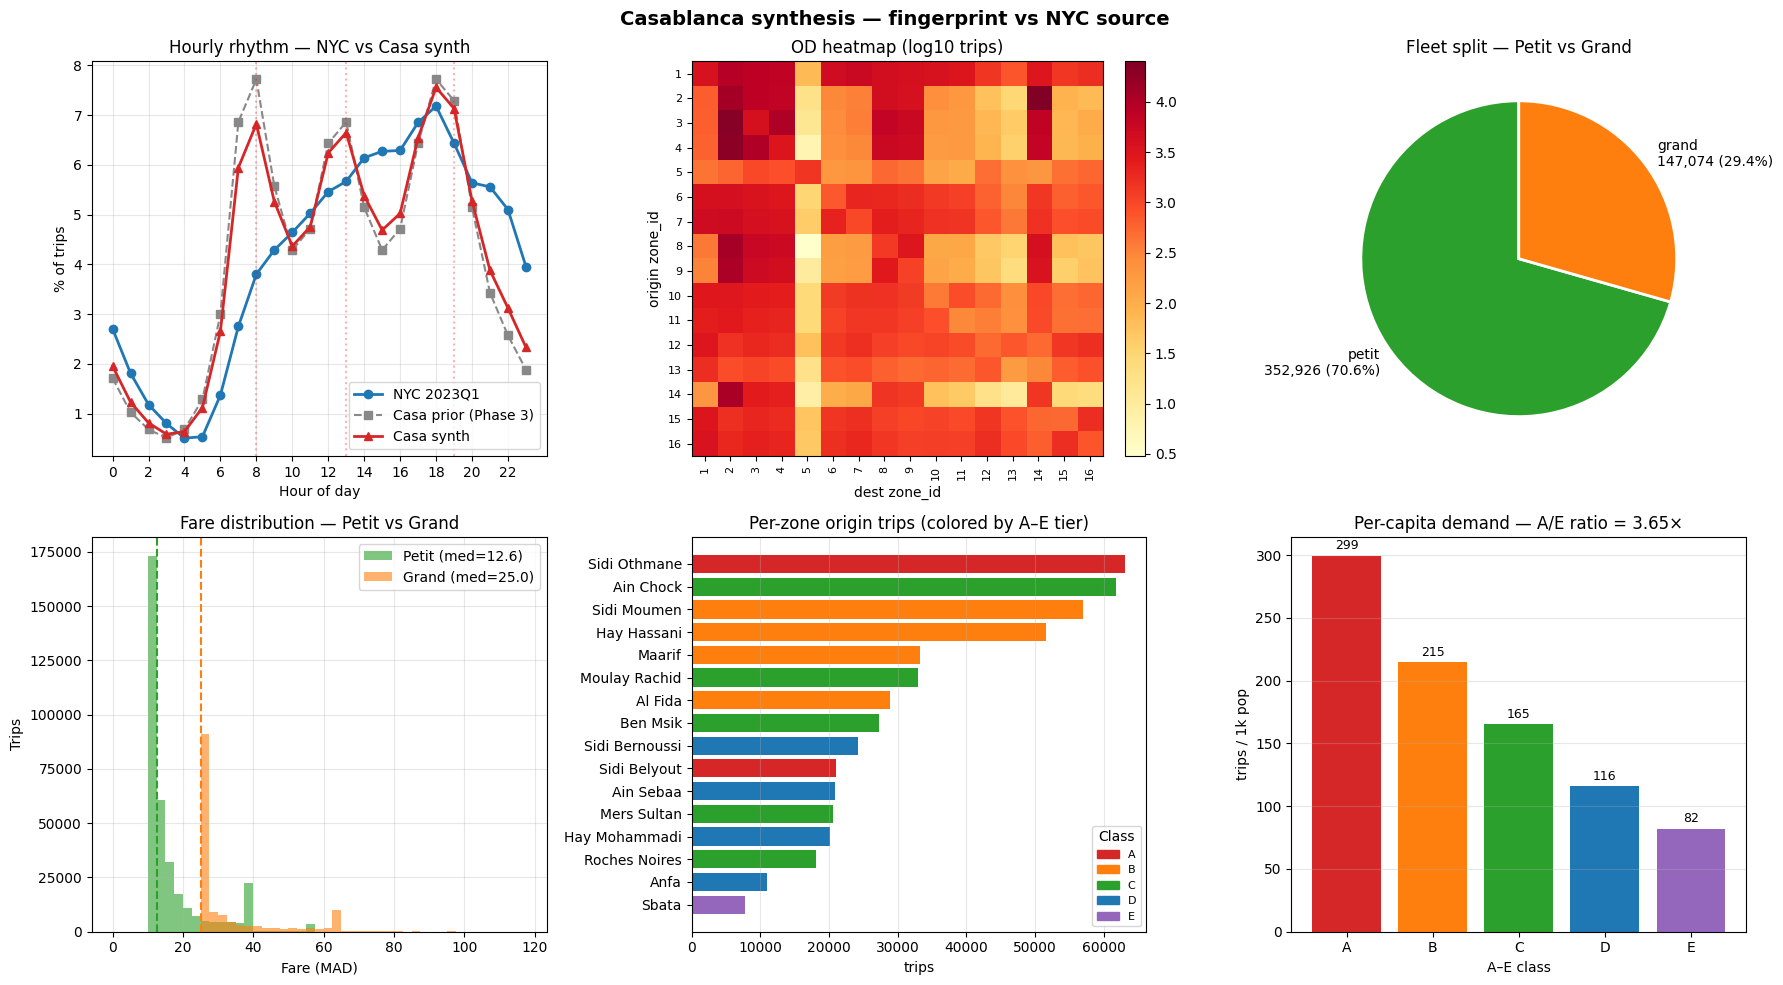


Figure saved: c:\Users\hp\OneDrive - Université Abdelmalek Essaadi\Desktop\Taasimm\data\casa_synthesis\eda_figures.png (198.9 KB)


In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Casablanca synthesis — fingerprint vs NYC source', fontsize=14, fontweight='bold')

# --- (1) Hourly overlay ---
ax = axes[0, 0]
casa_hour_p = trips_df['hour'].value_counts(normalize=True).sort_index().reindex(range(24), fill_value=0).to_numpy()
ax.plot(range(24), NYC_HOURLY_P * 100, 'o-', label='NYC 2023Q1', color='#1f77b4', lw=2)
ax.plot(range(24), CASA_HOURLY_PROFILE * 100, 's--', label='Casa prior (Phase 3)', color='#888888', lw=1.5)
ax.plot(range(24), casa_hour_p * 100, '^-', label='Casa synth', color='#d62728', lw=2)
for h in [8, 13, 19]:
    ax.axvline(h, ls=':', c='red', alpha=0.3)
ax.set_xlabel('Hour of day'); ax.set_ylabel('% of trips')
ax.set_title('Hourly rhythm — NYC vs Casa synth'); ax.legend(); ax.grid(alpha=0.3)
ax.set_xticks(range(0, 24, 2))

# --- (2) 16×16 OD heatmap ---
ax = axes[0, 1]
od_pivot = (trips_df.groupby(['origin_zone_id', 'dest_zone_id']).size()
            .unstack(fill_value=0).reindex(index=zone_ids, columns=zone_ids, fill_value=0))
im = ax.imshow(np.log10(od_pivot.to_numpy() + 1), cmap='YlOrRd', aspect='auto')
ax.set_title('OD heatmap (log10 trips)'); ax.set_xlabel('dest zone_id'); ax.set_ylabel('origin zone_id')
ax.set_xticks(range(16)); ax.set_yticks(range(16))
ax.set_xticklabels(zone_ids, rotation=90, fontsize=8); ax.set_yticklabels(zone_ids, fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046)

# --- (3) Fleet pie ---
ax = axes[0, 2]
fleet_counts = trips_df['fleet_type'].value_counts()
ax.pie(fleet_counts.values,
       labels=[f'{k}\n{v:,} ({v/len(trips_df)*100:.1f}%)' for k, v in fleet_counts.items()],
       colors=['#2ca02c', '#ff7f0e'], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Fleet split — Petit vs Grand')

# --- (4) Fare distributions ---
ax = axes[1, 0]
petit_fare = trips_df.loc[trips_df['fleet_type'] == 'petit', 'fare_mad']
grand_fare = trips_df.loc[trips_df['fleet_type'] == 'grand', 'fare_mad']
bins = np.arange(0, 120, 2.5)
ax.hist(petit_fare, bins=bins, alpha=0.6, label=f'Petit (med={petit_fare.median():.1f})', color='#2ca02c')
ax.hist(grand_fare, bins=bins, alpha=0.6, label=f'Grand (med={grand_fare.median():.1f})', color='#ff7f0e')
ax.axvline(petit_fare.median(), c='#2ca02c', ls='--')
ax.axvline(grand_fare.median(), c='#ff7f0e', ls='--')
ax.set_xlabel('Fare (MAD)'); ax.set_ylabel('Trips'); ax.set_title('Fare distribution — Petit vs Grand')
ax.legend(); ax.grid(alpha=0.3)

# --- (5) Per-zone trip volume (colored by A-E) ---
ax = axes[1, 1]
tier_colors = {'A': '#d62728', 'B': '#ff7f0e', 'C': '#2ca02c', 'D': '#1f77b4', 'E': '#9467bd'}
zone_vol = (trips_df.groupby(['origin_zone_id', 'origin_zone_name', 'origin_class']).size()
            .reset_index(name='trips').sort_values('trips', ascending=True))
colors = zone_vol['origin_class'].map(tier_colors)
ax.barh(zone_vol['origin_zone_name'], zone_vol['trips'], color=colors)
ax.set_title('Per-zone origin trips (colored by A–E tier)'); ax.set_xlabel('trips')
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in tier_colors.values()]
ax.legend(handles, tier_colors.keys(), title='Class', loc='lower right', fontsize=8)
ax.grid(axis='x', alpha=0.3)

# --- (6) Per-capita A–E demand ---
ax = axes[1, 2]
_pop_by_class   = zone_map_df.groupby('ae_class')['population_2024'].sum()
_trips_by_class = trips_df.groupby('origin_class').size()
_percap = (_trips_by_class / _pop_by_class * 1000).reindex(list('ABCDE')).fillna(0)
bars = ax.bar(_percap.index, _percap.values, color=[tier_colors[c] for c in _percap.index])
for b, v in zip(bars, _percap.values):
    ax.text(b.get_x() + b.get_width()/2, v + 5, f'{v:.0f}', ha='center', fontsize=9)
_ratio = _percap['A'] / _percap['E'] if _percap['E'] > 0 else float('nan')
ax.set_title(f'Per-capita demand — A/E ratio = {_ratio:.2f}×')
ax.set_xlabel('A–E class'); ax.set_ylabel('trips / 1k pop'); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig_path = OUT_DIR / 'eda_figures.png'
plt.savefig(fig_path, dpi=110, bbox_inches='tight')
plt.show()
print(f'\nFigure saved: {fig_path} ({fig_path.stat().st_size/1024:.1f} KB)')
